# Eikosany on the Hexadic Diamond — A₄ Coxeter Derivation

Reproduces the 10-variant Eikosany overlay on the Hexadic Diamond using SageMath A₄ root-system machinery. Companion to `hexadic_diamond_coxeter.ipynb`.

The key constructions:
- **Hexadic Diamond** = {0} ⊔ Λ₁ ⊔ Λ₄ ⊔ Φ(A₄) — origin + otonals + utonals + 20 roots, 31 points.
- **Eikosany** = Λ₂ ⊔ Λ₃ under A₄ ⊂ A₅ (Pascal: C(6,3) = C(5,2) + C(5,3) = 10 + 10), 20 points.
- **10 outer-ring divisors** generated by the Coxeter element c = s₁s₂s₃s₄ acting on two seeds:
  - ε₀ + ε₁ — a Λ₂ "adjacent" seed
  - ε₀ + ε₁ + ε₂ — a Λ₃ seed whose complement {3, 4} is cyclically adjacent

⟨c⟩ ≅ C₅ ⊂ W(A₄) is the symmetry that distinguishes "adjacent" from "non-adjacent" — the cyclic refinement of the full S₅ that survives projection to E∥. See `doc/eikosany_diamond_overlay.md` for theoretical background.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
from sympy import Rational

from coxeter_a4 import build_a4_system, build_eigenspaces, eigenvec_to_proj


## Build the A₄ root system and the 2D projection


In [2]:
R, ambient, W, s, cox, P = build_a4_system()
K, zeta, w_par, w_perp = build_eigenspaces(P)
proj = eigenvec_to_proj(w_par, K)

P_np = np.array(P, dtype=int)
eps = [ambient.basis()[i] for i in ambient.basis().keys()]

print('Coxeter element c = s₁ s₂ s₃ s₄ (acting cyclically: εᵢ → εᵢ₊₁):')
print(P_np)


Coxeter element c = s₁ s₂ s₃ s₄ (acting cyclically: εᵢ → εᵢ₊₁):
[[0 0 0 0 1]
 [1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]]


## The four fundamental-weight orbits Λ₁, Λ₂, Λ₃, Λ₄

Pascal row 5 = {1, 5, 10, 10, 5, 1} is the cardinality list of the small W(A₄)-orbits on the weight lattice. Musically:

- **Λ₁** (5 otonals): +εᵢ → primes 3, 5, 7, 9, 11
- **Λ₂** (10): εᵢ + εⱼ → Eikosany notes containing factor 1 (e.g. 1·3·5)
- **Λ₃** (10): εᵢ + εⱼ + εₖ → Eikosany notes not containing factor 1 (e.g. 3·5·7)
- **Λ₄** (5 utonals): equivalent mod 𝟙 to −εᵢ → 1/3, 1/5, 1/7, 1/9, 1/11

We construct each orbit as integer 5D vectors (raw form — k 1's and (5−k) 0's) and cross-check the cardinalities against Sage's `.orbit()` machinery.


In [3]:
Lambda = ambient.fundamental_weights()

def orbit_5D(k):
    """W(A₄)-orbit of the k-th fundamental weight Λₖ as integer 5D vectors."""
    return np.array([np.array(v.to_vector(), dtype=int)
                     for v in Lambda[k].orbit()])

L1 = orbit_5D(1)   # 5  otonals (Λ₁)
L2 = orbit_5D(2)   # 10 Eikosany "with 1" (Λ₂)
L3 = orbit_5D(3)   # 10 Eikosany "no 1" (Λ₃)
L4 = orbit_5D(4)   # 5  (≡ −εᵢ mod 𝟙)

print('Fundamental weights in ambient form:')
for k in (1, 2, 3, 4):
    print(f'  Λ{k} = {tuple(int(x) for x in Lambda[k].to_vector())}')
print()
print('Pascal row 5 ↔ A₄ fundamental-weight orbit sizes:')
print(f'  C(5,1) = {len(L1):2d}    (W·Λ₁: otonals)')
print(f'  C(5,2) = {len(L2):2d}    (W·Λ₂: Eikosany "with 1")')
print(f'  C(5,3) = {len(L3):2d}    (W·Λ₃: Eikosany "no 1")')
print(f'  C(5,4) = {len(L4):2d}    (W·Λ₄: utonals)')


Fundamental weights in ambient form:
  Λ1 = (1, 0, 0, 0, 0)
  Λ2 = (1, 1, 0, 0, 0)
  Λ3 = (1, 1, 1, 0, 0)
  Λ4 = (1, 1, 1, 1, 0)

Pascal row 5 ↔ A₄ fundamental-weight orbit sizes:
  C(5,1) =  5    (W·Λ₁: otonals)
  C(5,2) = 10    (W·Λ₂: Eikosany "with 1")
  C(5,3) = 10    (W·Λ₃: Eikosany "no 1")
  C(5,4) =  5    (W·Λ₄: utonals)


## Build the Hexadic Diamond and the Eikosany from A₄ orbits

For the Hexadic Diamond we use the literal −εᵢ form for utonals (matching `hexadic_diamond_coxeter.ipynb` and the diamond's "at most one positive and at most one negative entry" filter):

  Diamond = {0} ⊔ {+εᵢ} ⊔ {−εᵢ} ⊔ Φ(A₄)  →  1 + 5 + 5 + 20 = 31 points

For the Eikosany we use the raw Λ₂ ⊔ Λ₃ form (sums of εᵢ):

  Eikosany = Λ₂ ⊔ Λ₃  →  10 + 10 = 20 points


In [4]:
otonal_5D = L1                                              # +εᵢ
utonal_5D = -L1                                             # −εᵢ
roots_5D  = np.array([np.array(r.to_vector(), dtype=int)
                      for r in ambient.roots()])            # 20 roots (Φ)

diamond_5D = np.vstack([np.zeros((1, 5), dtype=int),
                        otonal_5D, utonal_5D, roots_5D])

eikosany_5D = np.vstack([L2, L3])

# Verify the diamond filter (at most one +1 and at most one −1 in each row)
assert all((np.sum(pt < 0) < 2) and (np.sum(pt > 0) < 2) for pt in diamond_5D)

print(f'Hexadic Diamond  : {len(diamond_5D)} points (expected 31)')
print(f'Eikosany         : {len(eikosany_5D)} points (expected 20)')


Hexadic Diamond  : 31 points (expected 31)
Eikosany         : 20 points (expected 20)


## The 10 outer-ring divisors via the Coxeter element

The 10 outer-ring Eikosany points are *not* a single W(A₄)-orbit — they combine 5 from Λ₂ and 5 from Λ₃. These could be selected
through selection based on distance-in-projection. Instead, we use the Coxeter element c = s₁s₂s₃s₄, whose cyclic group ⟨c⟩ ≅ C₅ ⊂ W(A₄) 
is the symmetry that distinguishes "adjacent" from "non-adjacent" cyclically.

Apply c to two seeds:
- **Λ₂ seed**: ε₀ + ε₁ (a cyclically adjacent 2-subset)
- **Λ₃ seed**: ε₀ + ε₁ + ε₂ (a 3-subset whose complement {3, 4} is cyclically adjacent)

Each generates a 5-element orbit; together they form the 10 outer-ring divisors — purely by an iteration inside W(A₄), no projection geometry required.


In [5]:
def coxeter_orbit(base, n=5):
    """C₅-orbit under repeated application of the Coxeter element P."""
    orbit = [np.array(base, dtype=int)]
    for _ in range(n - 1):
        orbit.append(P_np @ orbit[-1])
    return np.array(orbit, dtype=int)

seed_L2 = np.array((eps[0] + eps[1]).to_vector(),         dtype=int)   # Λ₂ adjacent
seed_L3 = np.array((eps[0] + eps[1] + eps[2]).to_vector(), dtype=int)   # Λ₃ complement-{3,4}

orbit_L2_outer = coxeter_orbit(seed_L2)
orbit_L3_outer = coxeter_orbit(seed_L3)

outer_ring_divisors = np.vstack([orbit_L2_outer, orbit_L3_outer])

# Convert to musical ratios for display
primes = [3, 5, 7, 9, 11]
def ratio(v_5D):
    num = den = 1
    for p, e in zip(primes, v_5D):
        if   e > 0: num *= p ** int(e)
        elif e < 0: den *= p ** int(-e)
    return Rational(num, den)

print('10 outer-ring divisors generated via Coxeter element c on two seeds:')
print(f'  Λ₂ seed = ε₀ + ε₁         = {tuple(seed_L2)}  →  {ratio(seed_L2)}')
for k, v in enumerate(orbit_L2_outer):
    print(f'    c^{k}·seed_Λ₂ = {tuple(v)}  →  {ratio(v)}')
print()
print(f'  Λ₃ seed = ε₀ + ε₁ + ε₂   = {tuple(seed_L3)}  →  {ratio(seed_L3)}')
for k, v in enumerate(orbit_L3_outer):
    print(f'    c^{k}·seed_Λ₃ = {tuple(v)}  →  {ratio(v)}')


10 outer-ring divisors generated via Coxeter element c on two seeds:
  Λ₂ seed = ε₀ + ε₁         = (np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0))  →  15
    c^0·seed_Λ₂ = (np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0))  →  15
    c^1·seed_Λ₂ = (np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0))  →  35
    c^2·seed_Λ₂ = (np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0))  →  63
    c^3·seed_Λ₂ = (np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(1))  →  99
    c^4·seed_Λ₂ = (np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1))  →  33

  Λ₃ seed = ε₀ + ε₁ + ε₂   = (np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0))  →  105
    c^0·seed_Λ₃ = (np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0))  →  105
    c^1·seed_Λ₃ = (np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0))  →  315
    c^2·seed_Λ₃ = (np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1))  

## Plot all 10 variants on a single figure

Each variant is the Eikosany translated by subtracting one outer-ring divisor in 5D, then projected to E∥ via the cyclotomic eigenvector. The Hexadic Diamond appears as a light-grey skeleton.


Total Eikosany-points across 10 variants : 200  (= 10 × 20)
Distinct points (5D)                     : 111
  ↳ coincident with Hexadic Diamond      : 31  / 31 diamond points
  ↳ outside the Hexadic Diamond          : 80


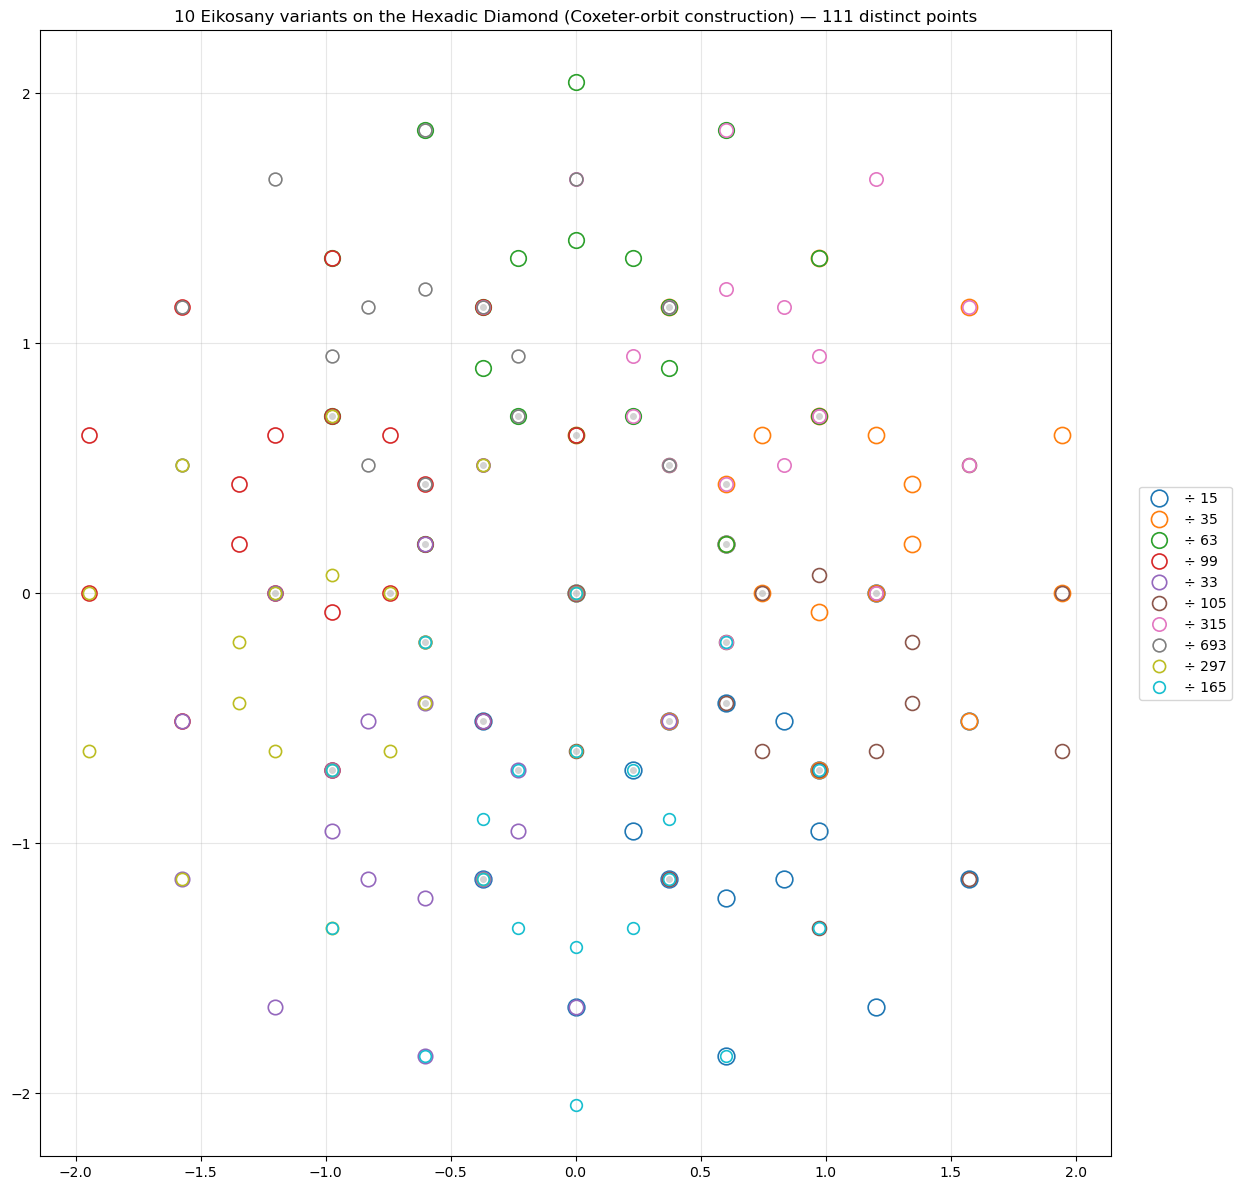

In [6]:
fig, ax = plt.subplots(figsize=(12, 12))

# Hexadic Diamond skeleton (90° rotation matches Wilson's orientation)
xy_d = (proj @ diamond_5D.T).T
xD_, yD_ = -xy_d[:, 1], xy_d[:, 0]
ax.plot(xD_, yD_, '.', color='lightgrey', markersize=8, zorder=0)

all_5D = []
cmap = plt.cm.tab10

for k, divisor in enumerate(outer_ring_divisors):
    var_5D = eikosany_5D - divisor
    xy_v = (proj @ var_5D.T).T
    xv_, yv_ = -xy_v[:, 1], xy_v[:, 0]

    color = cmap(k % 10)
    label = f'÷ {ratio(divisor)}'
    ax.plot(xv_, yv_, 'o', markerfacecolor='none', markeredgecolor=color,
            markersize=12 - k * 0.4, markeredgewidth=1.2,
            label=label, zorder=1 + k)

    all_5D.extend(tuple(int(x) for x in row) for row in var_5D)

# Distinct-point bookkeeping
unique_5D    = set(all_5D)
diamond_set  = {tuple(int(x) for x in r) for r in diamond_5D}
on_diamond   = unique_5D & diamond_set
off_diamond  = unique_5D - diamond_set

print(f'Total Eikosany-points across 10 variants : {len(all_5D)}  (= 10 × 20)')
print(f'Distinct points (5D)                     : {len(unique_5D)}')
print(f'  ↳ coincident with Hexadic Diamond      : {len(on_diamond)}  / {len(diamond_set)} diamond points')
print(f'  ↳ outside the Hexadic Diamond          : {len(off_diamond)}')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)
ax.set_title(f'10 Eikosany variants on the Hexadic Diamond '
             f'(Coxeter-orbit construction) — {len(unique_5D)} distinct points')
plt.tight_layout()
plt.show()


## Verify: Coxeter-based selection ≡ distance-based selection

The two constructions of the outer ring should produce identical 10-point sets.


In [7]:
xy_E  = (proj @ eikosany_5D.T).T
mag_E = np.linalg.norm(xy_E, axis=1)
distance_outer = eikosany_5D[np.argsort(mag_E)[-10:]]

distance_set = {tuple(int(x) for x in v) for v in distance_outer}
coxeter_set  = {tuple(int(x) for x in v) for v in outer_ring_divisors}

print(f'Distance-based outer ring : {len(distance_set)} points')
print(f'Coxeter-based outer ring  : {len(coxeter_set)} points')
print(f'Identical sets            : {distance_set == coxeter_set}')
print()

# Magnitudes confirmation: outer ≈ τ × inner
mags_outer = sorted({round(float(np.linalg.norm(proj @ v)), 4)
                     for v in outer_ring_divisors})
mags_inner = sorted({round(float(np.linalg.norm(proj @ v)), 4)
                     for v in eikosany_5D
                     if tuple(int(x) for x in v) not in coxeter_set})
print(f'Outer-ring magnitudes : {mags_outer}')
print(f'Inner-ring magnitudes : {mags_inner}')
print(f'Ratio (outer / inner) = {mags_outer[0] / mags_inner[0]:.4f}'
      f'   (expect τ² = {((1 + 5**0.5) / 2)**2:.4f})')


Distance-based outer ring : 10 points
Coxeter-based outer ring  : 10 points
Identical sets            : True

Outer-ring magnitudes : [1.0233]
Inner-ring magnitudes : [0.3909]
Ratio (outer / inner) = 2.6178   (expect τ² = 2.6180)


## Outer-ring divisors with Wilson-form labels (for HEJI notation)

Each of the 10 outer-ring divisors is a product of generators from {3, 5, 7, 9, 11} — either two of them (Λ₂, with the "1" generator implicit) or three of them (Λ₃). For Helmholtz–Ellis notation, the relevant data is the prime-factor pattern; the Wilson form gives this directly except that 9 = 3² will need a final decomposition step (each "9" contributes two 3-prime sigmas).


10 outer-ring divisors:
  Wilson form   integer  orbit
  3·5                15  Λ₂
  5·7                35  Λ₂
  7·9                63  Λ₂
  9·11               99  Λ₂
  3·11               33  Λ₂
  3·5·7             105  Λ₃
  5·7·9             315  Λ₃
  7·9·11            693  Λ₃
  3·9·11            297  Λ₃
  3·5·11            165  Λ₃


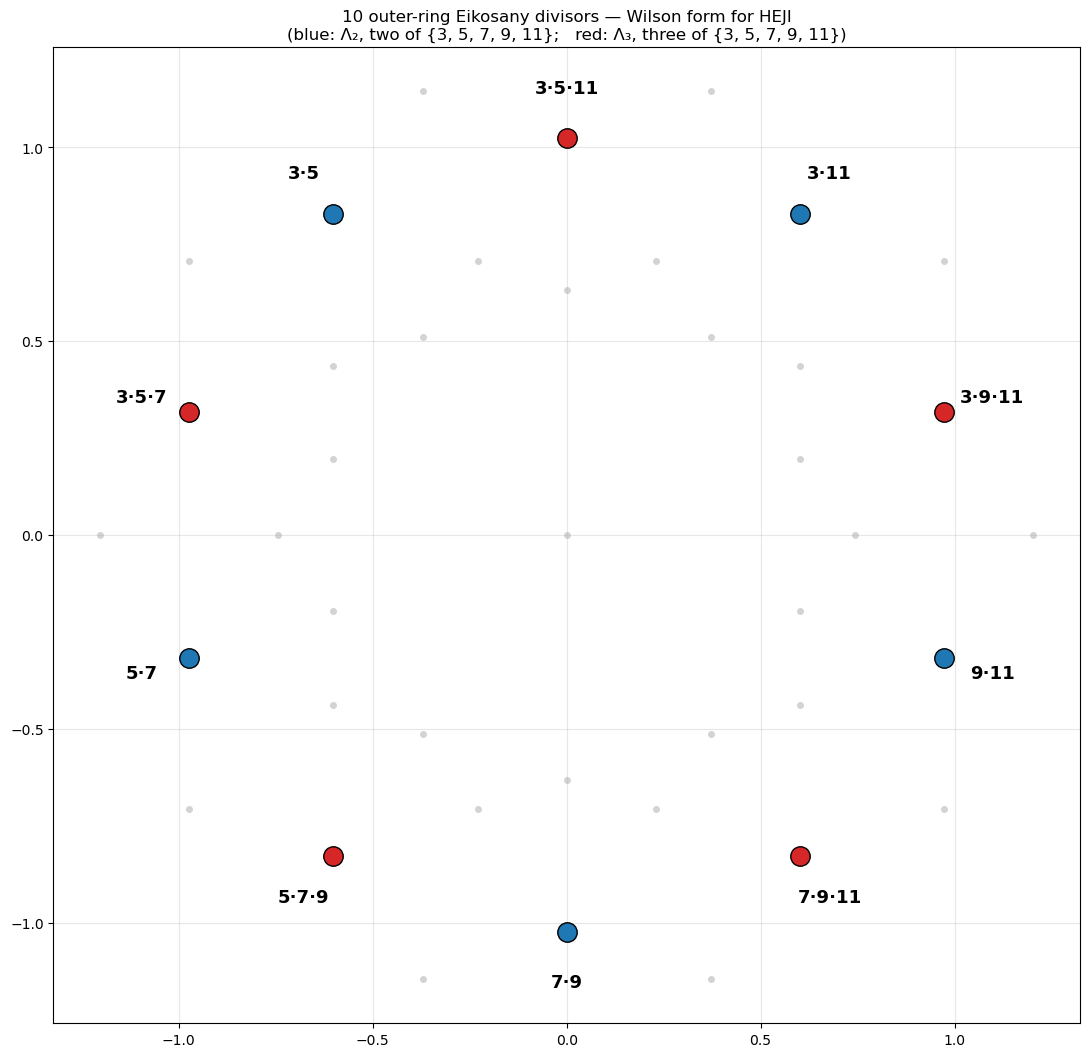

In [8]:
def wilson_form(v_5D):
    """5D Eikosany vector → product over Wilson generators {3, 5, 7, 9, 11}."""
    gens = [3, 5, 7, 9, 11]
    factors = [str(gens[i]) for i, e in enumerate(v_5D) if e > 0]
    return '·'.join(factors) if factors else '1'

# Print the 10 divisors with Wilson form, integer, and orbit label
print('10 outer-ring divisors:')
print(f'  {"Wilson form":<12}  {"integer":>7}  orbit')
for v in outer_ring_divisors:
    kind = 'Λ₂' if int(v.sum()) == 2 else 'Λ₃'
    print(f'  {wilson_form(v):<12}  {int(ratio(v)):>7}  {kind}')

# Plot diamond skeleton + labeled divisor positions
fig, ax = plt.subplots(figsize=(11, 11))

xy_d = (proj @ diamond_5D.T).T
xD_, yD_ = -xy_d[:, 1], xy_d[:, 0]
ax.plot(xD_, yD_, '.', color='lightgrey', markersize=8, zorder=0)

xy_div = (proj @ outer_ring_divisors.T).T
xDv_, yDv_ = -xy_div[:, 1], xy_div[:, 0]

for x, y, v in zip(xDv_, yDv_, outer_ring_divisors):
    color = 'tab:blue' if int(v.sum()) == 2 else 'tab:red'
    ax.plot(x, y, 'o', markerfacecolor=color, markeredgecolor='black',
            markersize=14, zorder=2)
    # Place label radially outward from the divisor position
    rho = float(np.sqrt(x**2 + y**2))
    dx, dy = x / rho * 0.13, y / rho * 0.13
    ax.text(x + dx, y + dy, wilson_form(v),
            fontsize=13, ha='center', va='center', fontweight='bold')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('10 outer-ring Eikosany divisors — Wilson form for HEJI\n'
             '(blue: Λ₂, two of {3, 5, 7, 9, 11};   red: Λ₃, three of {3, 5, 7, 9, 11})')
plt.tight_layout()
plt.show()


## Sorted list of all distinct points with HEJI factorizations

For each distinct point in the 10-variant overlay, give the octave-reduced JI ratio together with prime factorisations of numerator (otonal accidentals) and denominator (utonal accidentals). The Wilson generator 9 is decomposed to its true-prime form 3².

Two notes about Wilson redundancy from 9 = 3²:

1. **Some ratios are reached at multiple 5D positions on the figure** — e.g. ratio 22/21 has two distinct 5D representatives `(-1, 0, -1, 0, 1)` and `(1, 0, -1, -1, 1)`, both reducing to prime form `11/(3·7)`. The `mult` column gives the count.
2. **Even within the Hexadic Diamond itself, 31 5D vectors collapse to 29 distinct pitches**: the root `ε₃ − ε₀` (= 9/3) shares a prime form with the otonal `ε₀` (= 3), and `ε₀ − ε₃` (= 3/9) shares with the utonal `−ε₀`. So the ✓ count below is 29, not 31.

The diamond column (`✓`) marks ratios reachable from at least one diamond 5D point.


In [9]:
def prime_exponents(v_5D):
    """5D Wilson vector → true-prime exponent dict over {3, 5, 7, 11}."""
    return {
        3:  int(v_5D[0]) + 2 * int(v_5D[3]),   # 9 = 3² absorbed into 3-prime
        5:  int(v_5D[1]),
        7:  int(v_5D[2]),
        11: int(v_5D[4]),
    }

_SUP = str.maketrans('0123456789-', '⁰¹²³⁴⁵⁶⁷⁸⁹⁻')

def factor_str(exp_dict):
    """{p: positive_e} → '3²·5·7' (or '—' if empty)."""
    parts = []
    for p in (3, 5, 7, 11):
        e = exp_dict.get(p, 0)
        if e == 0: continue
        elif e == 1: parts.append(str(p))
        else:        parts.append(f'{p}{str(e).translate(_SUP)}')
    return '·'.join(parts) if parts else '—'

def split_oton_uton(v_5D):
    e = prime_exponents(v_5D)
    return ({p: ex for p, ex in e.items() if ex > 0},
            {p: -ex for p, ex in e.items() if ex < 0})

def octave_reduced(v_5D):
    """Octave-reduced JI ratio in [1, 2) as sympy Rational."""
    e = prime_exponents(v_5D)
    n = d = 1
    for p, ex in e.items():
        if   ex > 0: n *= p ** ex
        elif ex < 0: d *= p ** abs(ex)
    r = Rational(n, d)
    while r >= 2: r /= 2
    while r < 1:  r *= 2
    return r

# Aggregate distinct 5D points across all 10 variants
distinct = set()
for divisor in outer_ring_divisors:
    for q in eikosany_5D - divisor:
        distinct.add(tuple(int(x) for x in q))
distinct = [np.array(t, dtype=int) for t in distinct]

# Group by prime form (same prime exponents ⇒ same JI pitch & same HEJI accidentals)
groups = {}
for v in distinct:
    e = prime_exponents(v)
    key = (e[3], e[5], e[7], e[11])
    groups.setdefault(key, []).append(v)

# Sort groups by octave-reduced ratio
sorted_groups = sorted(groups.items(),
                       key=lambda kv: float(octave_reduced(kv[1][0])))

# Diamond membership: a ratio is on the diamond if any of its 5D forms is
diamond_set = {tuple(int(x) for x in r) for r in diamond_5D}

print(f'  ✓  {"ratio":<10}  {"otonal (num.)":<16}  {"utonal (den.)":<16}  mult')
print('  ─  ' + '─' * 10 + '  ' + '─' * 16 + '  ' + '─' * 16 + '  ────')

n_d = n_o = 0
for _, vs in sorted_groups:
    v0    = vs[0]
    on_d  = any(tuple(int(x) for x in v) in diamond_set for v in vs)
    mark  = '✓' if on_d else ' '
    if on_d: n_d += 1
    else:    n_o += 1
    oton, uton = split_oton_uton(v0)
    r     = octave_reduced(v0)
    mult  = f'×{len(vs)}' if len(vs) > 1 else ''
    print(f'  {mark}  {str(r):<10}  {factor_str(oton):<16}  {factor_str(uton):<16}  {mult}')

print()
print(f'Distinct ratios          : {len(sorted_groups)}')
print(f'  ✓ matching diamond     : {n_d}'
      f'   (31 diamond 5D points collapse to {n_d} ratios via 9 = 3²)')
print(f'  off-diamond             : {n_o}')
print(f'Distinct 5D positions    : {len(distinct)}'
      f'   (multiplicity ×N in column above)')


  ✓  ratio       otonal (num.)     utonal (den.)     mult
  ─  ──────────  ────────────────  ────────────────  ────
  ✓  1           —                 —                 
     56/55       7                 5·11              
     45/44       3²·5              11                
     36/35       3²                5·7               
     33/32       3·11              —                 
     28/27       7                 3³                
     80/77       5                 7·11              
     22/21       11                3·7               ×2
     21/20       3·7               5                 
     35/33       5·7               3·11              ×2
     297/280     3³·11             5·7               
     16/15       —                 3·5               
     15/14       3·5               7                 
  ✓  12/11       3                 11                ×2
  ✓  11/10       11                5                 
  ✓  10/9        5                 3²                
  ✓  9/8      

## Follow-up: inner-ring divisors (the other C₅-orbit pair)

The 10 inner-ring Eikosany points (radius 1/τ in E∥) are generated by the same Coxeter-orbit machinery applied to **non-adjacent** seeds:

| Ring | Λ₂ seed | Λ₃ seed |
|---|---|---|
| outer (radius τ) | ε₀ + ε₁ | ε₀ + ε₁ + ε₂ |
| **inner (radius 1/τ)** | **ε₀ + ε₂** | **ε₀ + ε₁ + ε₃** |

Each inner-ring divisor produces another overlay variant. The combinatorial counts of §7 depend only on |P| ∈ {2, 3} (not on adjacency), so each inner-ring variant again shares 10 of 20 with the diamond — but the per-diamond-point *multiplicity* pattern is Galois-conjugated relative to the outer ring.


10 inner-ring divisors (non-adjacent seeds):
  Wilson         int  orbit   |proj|
  3·7             21     Λ₂   0.3909
  5·9             45     Λ₂   0.3909
  7·11            77     Λ₂   0.3909
  3·9             27     Λ₂   0.3909
  5·11            55     Λ₂   0.3909
  3·5·9          135     Λ₃   0.3909
  5·7·11         385     Λ₃   0.3909
  3·7·9          189     Λ₃   0.3909
  5·9·11         495     Λ₃   0.3909
  3·7·11         231     Λ₃   0.3909

Outer / inner radius ratio: 2.6180   (expect τ² = 2.6180)


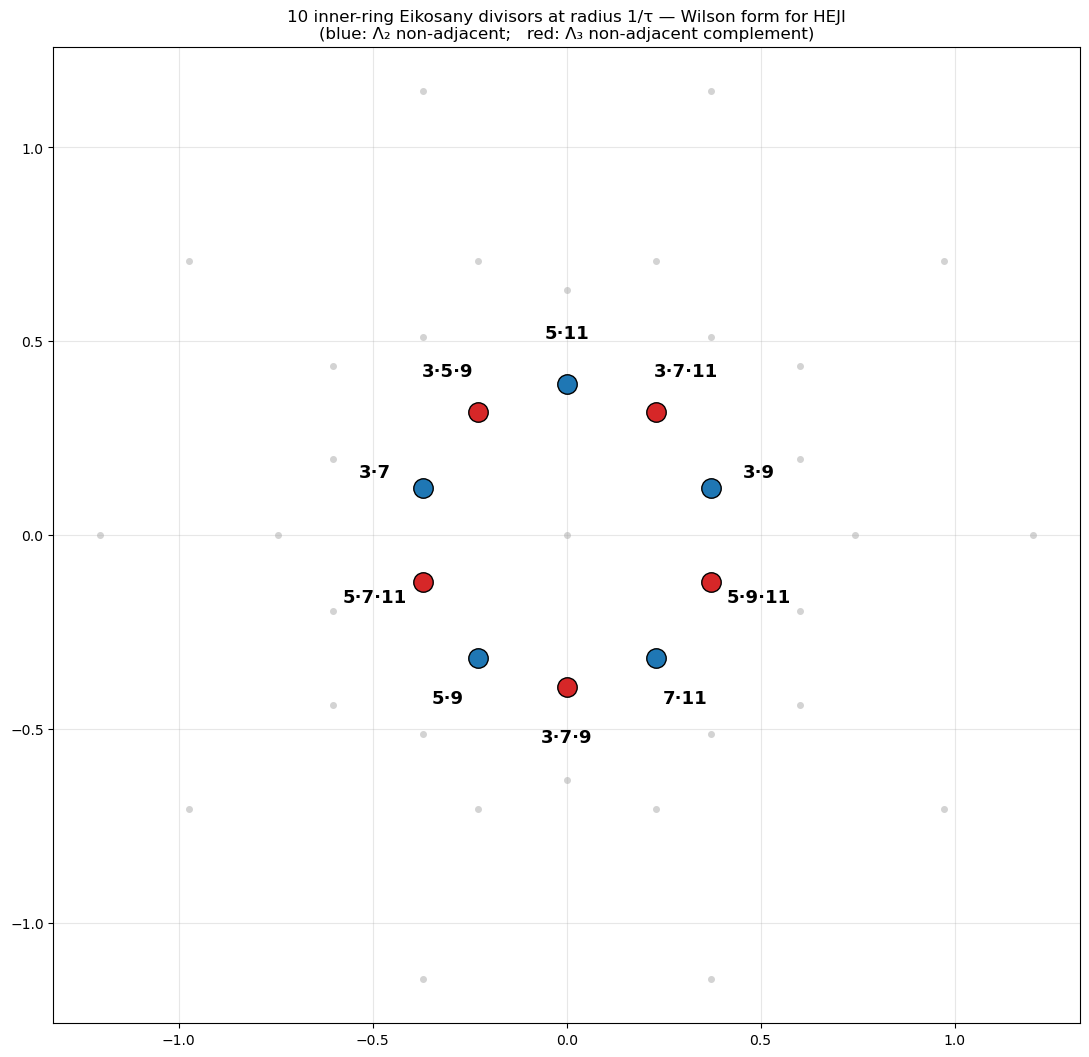

In [10]:
# Inner-ring divisors via Coxeter element on NON-adjacent seeds
seed_L2_inner = np.array((eps[0] + eps[2]).to_vector(),         dtype=int)   # Λ₂ non-adjacent
seed_L3_inner = np.array((eps[0] + eps[1] + eps[3]).to_vector(), dtype=int)   # Λ₃ non-adj. complement

orbit_L2_inner = coxeter_orbit(seed_L2_inner)
orbit_L3_inner = coxeter_orbit(seed_L3_inner)
inner_ring_divisors = np.vstack([orbit_L2_inner, orbit_L3_inner])

print('10 inner-ring divisors (non-adjacent seeds):')
print(f'  {"Wilson":<10}  {"int":>6}  {"orbit":>5}  {"|proj|":>7}')
for v in inner_ring_divisors:
    kind = 'Λ₂' if int(v.sum()) == 2 else 'Λ₃'
    mag  = float(np.linalg.norm(proj @ v))
    print(f'  {wilson_form(v):<10}  {int(ratio(v)):>6}  {kind:>5}  {mag:>7.4f}')

mag_outer = float(np.linalg.norm(proj @ outer_ring_divisors[0]))
mag_inner = float(np.linalg.norm(proj @ inner_ring_divisors[0]))
print(f'\nOuter / inner radius ratio: {mag_outer / mag_inner:.4f}'
      f'   (expect τ² = {((1+5**0.5)/2)**2:.4f})')

# Plot diamond skeleton + inner-ring divisor positions, Wilson labels
fig, ax = plt.subplots(figsize=(11, 11))
xy_d = (proj @ diamond_5D.T).T
xD_, yD_ = -xy_d[:, 1], xy_d[:, 0]
ax.plot(xD_, yD_, '.', color='lightgrey', markersize=8, zorder=0)

xy_div = (proj @ inner_ring_divisors.T).T
xDv_, yDv_ = -xy_div[:, 1], xy_div[:, 0]

for x, y, v in zip(xDv_, yDv_, inner_ring_divisors):
    color = 'tab:blue' if int(v.sum()) == 2 else 'tab:red'
    ax.plot(x, y, 'o', markerfacecolor=color, markeredgecolor='black',
            markersize=14, zorder=2)
    rho = float(np.sqrt(x**2 + y**2))
    dx, dy = x / rho * 0.13, y / rho * 0.13
    ax.text(x + dx, y + dy, wilson_form(v),
            fontsize=13, ha='center', va='center', fontweight='bold')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('10 inner-ring Eikosany divisors at radius 1/τ — Wilson form for HEJI\n'
             '(blue: Λ₂ non-adjacent;   red: Λ₃ non-adjacent complement)')
plt.tight_layout()
plt.show()


### Per-variant hit count and the Galois multiplicity swap

Each inner-ring variant shares 10 of 20 points with the diamond — same `1 + 6 + 3` decomposition as the outer ring. The interesting result is in *per-diamond-point* multiplicity:

- Outer-ring family privileges the d=2 (length τ) roots — 4 hits each.
- Inner-ring family privileges the d=1 (length 1) roots — 4 hits each.

The two patterns swap exactly. This is τ ↔ 1/τ Galois conjugation acting on the multiplicity distribution. Adding the two rings together gives **6 hits per non-origin diamond point** uniformly — Galois-symmetric coverage.


In [11]:
from collections import Counter

def diamond_kind(t):
    a = np.array(t)
    if (a == 0).all(): return 'origin'
    if a.sum() == 1 and (a > 0).sum() == 1: return 'otonal (Λ₁)'
    if a.sum() == -1 and (a < 0).sum() == 1: return 'utonal (Λ₄)'
    if a.sum() == 0:
        i = int(np.where(a > 0)[0][0]); j = int(np.where(a < 0)[0][0])
        d = min((i - j) % 5, (j - i) % 5)
        return f'root d={d}'
    return 'other'

def hit_breakdown(divisors):
    c = Counter()
    n_var = []
    for D in divisors:
        n = 0
        for q in eikosany_5D - D:
            t = tuple(int(x) for x in q)
            if t in diamond_set:
                c[diamond_kind(t)] += 1
                n += 1
        n_var.append(n)
    return c, n_var

inner_break, inner_hits = hit_breakdown(inner_ring_divisors)
outer_break, outer_hits = hit_breakdown(outer_ring_divisors)

print('Per-variant hit count (out of 20 Eikosany points):')
print(f'  inner ring : {inner_hits}  →  {sum(inner_hits)} total')
print(f'  outer ring : {outer_hits}  →  {sum(outer_hits)} total')

print('\nDiamond-piece multiplicity (hits per point):')
print(f'  {"piece":<14}  {"# pts":>5}   {"inner":>6}  {"outer":>6}  {"sum":>5}')
print('  ' + '─' * 48)
n_pts = {'origin':1, 'otonal (Λ₁)':5, 'utonal (Λ₄)':5, 'root d=1':10, 'root d=2':10}
for k in ['origin', 'otonal (Λ₁)', 'utonal (Λ₄)', 'root d=1', 'root d=2']:
    npts = n_pts[k]
    inner_per = inner_break[k] / npts
    outer_per = outer_break[k] / npts
    swap = '  ←swap' if k.startswith('root') else ''
    print(f'  {k:<14}  {npts:>5}   {inner_per:>6.1f}  {outer_per:>6.1f}  {inner_per+outer_per:>5.1f}{swap}')


Per-variant hit count (out of 20 Eikosany points):
  inner ring : [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]  →  100 total
  outer ring : [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]  →  100 total

Diamond-piece multiplicity (hits per point):
  piece           # pts    inner   outer    sum
  ────────────────────────────────────────────────
  origin              1     10.0    10.0   20.0
  otonal (Λ₁)         5      3.0     3.0    6.0
  utonal (Λ₄)         5      3.0     3.0    6.0
  root d=1           10      4.0     2.0    6.0  ←swap
  root d=2           10      2.0     4.0    6.0  ←swap


### Joint coverage and combined-divisors figure

Both rings independently saturate the diamond (31/31 each). Their joint coverage extends the off-diamond reach beyond either alone.


Distinct point coverage:
  inner ring   :  111 distinct  →  31/31 on diamond
  outer ring   :  111 distinct  →  31/31 on diamond
  inner ∪ outer:  141 distinct  →  31/31 on diamond
  shared       :   81  in both ring families
  unique inner :   30  off-diamond points reached only by inner ring
  unique outer :   30  off-diamond points reached only by outer ring


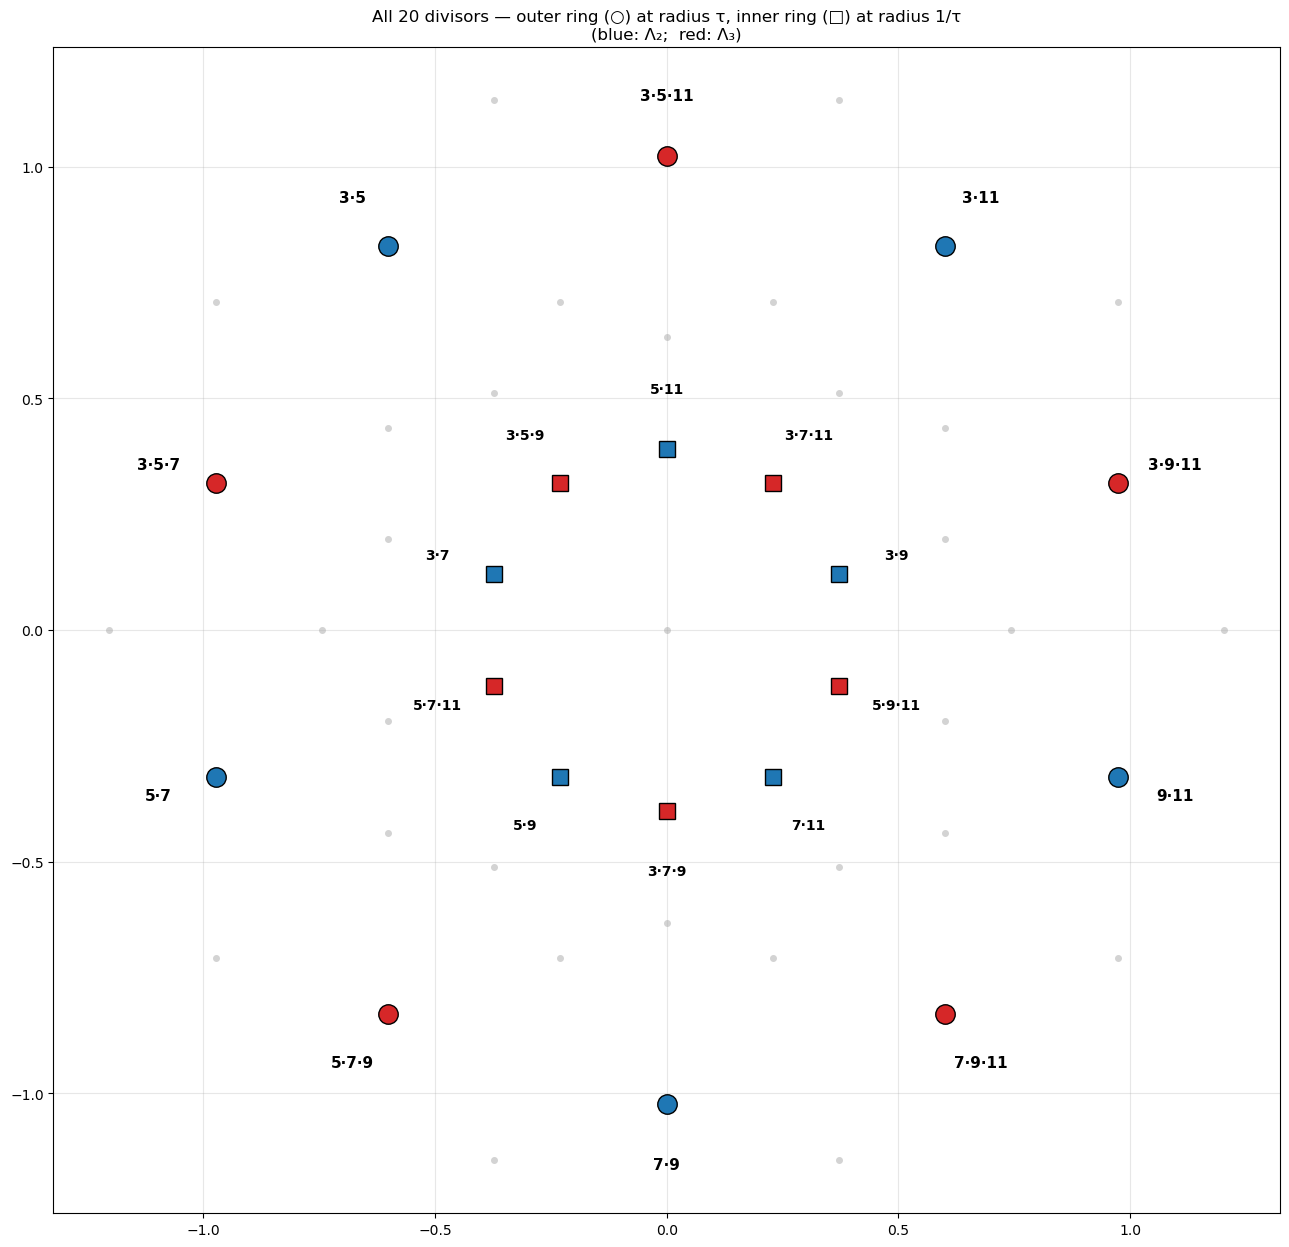

In [12]:
inner_pts = set()
for D in inner_ring_divisors:
    for q in eikosany_5D - D:
        inner_pts.add(tuple(int(x) for x in q))

outer_pts = set()
for D in outer_ring_divisors:
    for q in eikosany_5D - D:
        outer_pts.add(tuple(int(x) for x in q))

joint_pts = inner_pts | outer_pts

print('Distinct point coverage:')
print(f'  inner ring   : {len(inner_pts):4d} distinct  →  {len(inner_pts & diamond_set)}/{len(diamond_set)} on diamond')
print(f'  outer ring   : {len(outer_pts):4d} distinct  →  {len(outer_pts & diamond_set)}/{len(diamond_set)} on diamond')
print(f'  inner ∪ outer: {len(joint_pts):4d} distinct  →  {len(joint_pts & diamond_set)}/{len(diamond_set)} on diamond')
print(f'  shared       : {len(inner_pts & outer_pts):4d}  in both ring families')
print(f'  unique inner : {len(inner_pts - outer_pts):4d}  off-diamond points reached only by inner ring')
print(f'  unique outer : {len(outer_pts - inner_pts):4d}  off-diamond points reached only by outer ring')

# Combined plot: outer-ring (○) and inner-ring (□) divisors, Wilson labels
fig, ax = plt.subplots(figsize=(13, 13))

xy_d = (proj @ diamond_5D.T).T
xD_, yD_ = -xy_d[:, 1], xy_d[:, 0]
ax.plot(xD_, yD_, '.', color='lightgrey', markersize=8, zorder=0)

# Outer-ring divisors: circles, labels outward
xy_o = (proj @ outer_ring_divisors.T).T
xo_, yo_ = -xy_o[:, 1], xy_o[:, 0]
for x, y, v in zip(xo_, yo_, outer_ring_divisors):
    color = 'tab:blue' if int(v.sum()) == 2 else 'tab:red'
    ax.plot(x, y, 'o', markerfacecolor=color, markeredgecolor='black',
            markersize=14, zorder=2)
    rho = float(np.sqrt(x**2 + y**2))
    dx, dy = x / rho * 0.13, y / rho * 0.13
    ax.text(x + dx, y + dy, wilson_form(v),
            fontsize=11, ha='center', va='center', fontweight='bold')

# Inner-ring divisors: squares, labels outward
xy_i = (proj @ inner_ring_divisors.T).T
xi_, yi_ = -xy_i[:, 1], xy_i[:, 0]
for x, y, v in zip(xi_, yi_, inner_ring_divisors):
    color = 'tab:blue' if int(v.sum()) == 2 else 'tab:red'
    ax.plot(x, y, 's', markerfacecolor=color, markeredgecolor='black',
            markersize=12, zorder=2)
    rho = float(np.sqrt(x**2 + y**2))
    dx, dy = x / rho * 0.13, y / rho * 0.13
    ax.text(x + dx, y + dy, wilson_form(v),
            fontsize=10, ha='center', va='center', fontweight='bold')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title('All 20 divisors — outer ring (○) at radius τ, inner ring (□) at radius 1/τ\n'
             '(blue: Λ₂;  red: Λ₃)')
plt.tight_layout()
plt.show()


Total Eikosany-points across 20 variants : 400  (= 20 × 20)
Distinct 5D positions                    : 141
  ↳ on diamond                           : 31 / 31
  ↳ off diamond                          : 110


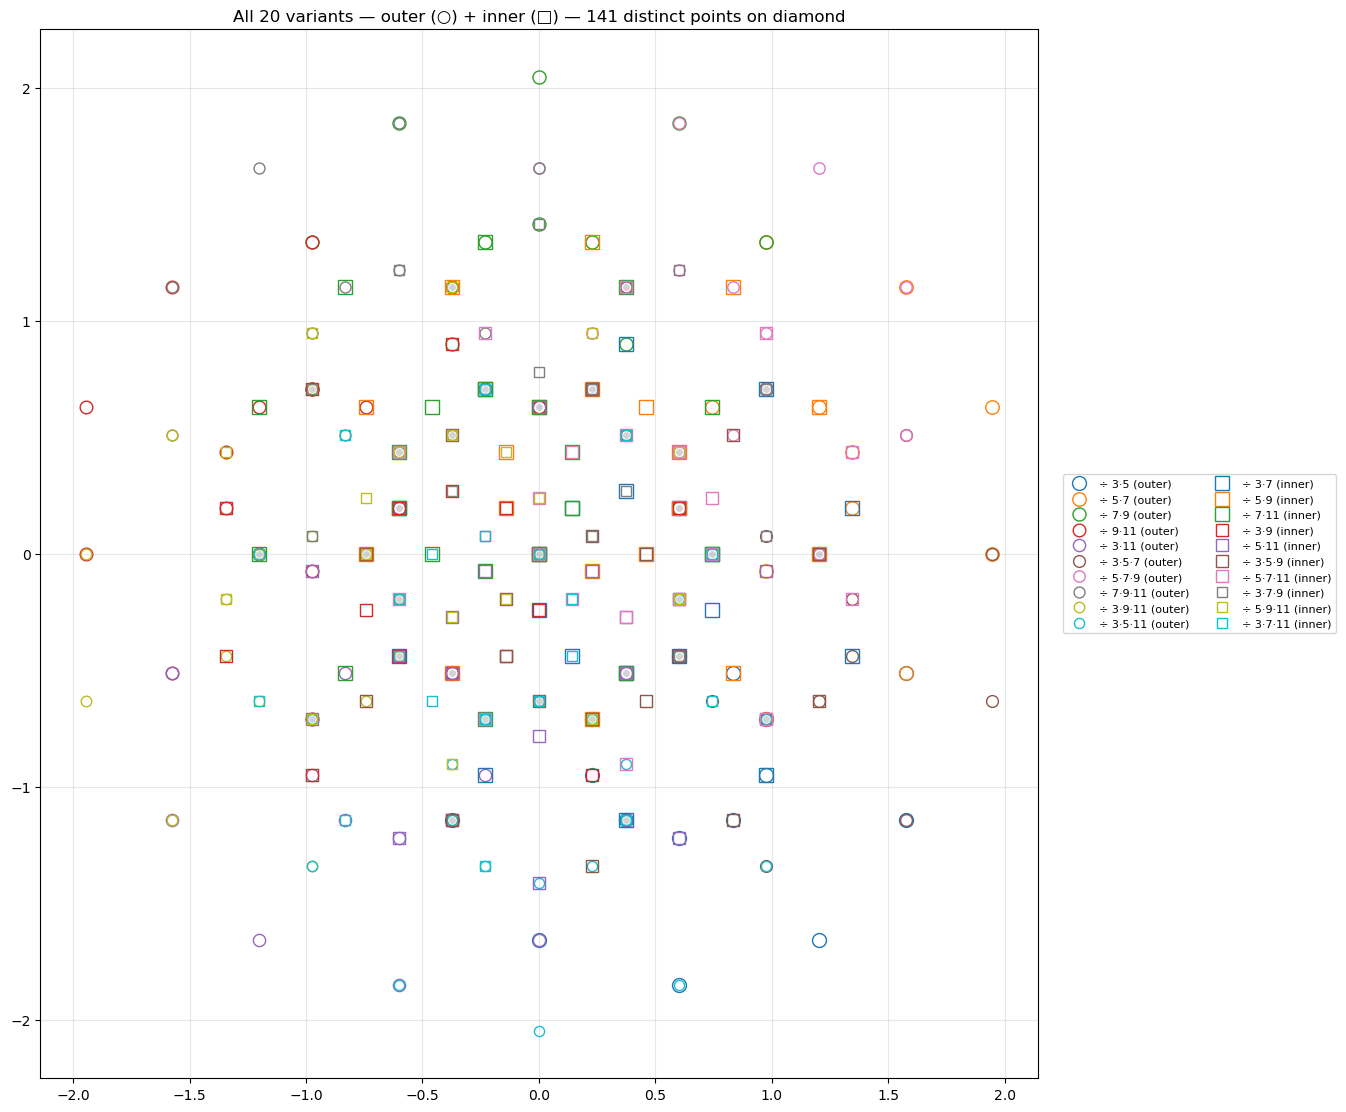

In [13]:
# All 20 variants (10 outer + 10 inner) on a single plot.
# Outer ring as circles, inner ring as squares; tab10 colormap reused for each.

all_divisors = np.vstack([outer_ring_divisors, inner_ring_divisors])

fig, ax = plt.subplots(figsize=(13, 13))
xy_d = (proj @ diamond_5D.T).T
xD_, yD_ = -xy_d[:, 1], xy_d[:, 0]
ax.plot(xD_, yD_, '.', color='lightgrey', markersize=8, zorder=0)

all_5D = []
cmap = plt.cm.tab10

for k, divisor in enumerate(all_divisors):
    var_5D = eikosany_5D - divisor
    xy_v   = (proj @ var_5D.T).T
    xv_, yv_ = -xy_v[:, 1], xy_v[:, 0]

    if k < 10:
        color, marker, ring = cmap(k),       'o', 'outer'
    else:
        color, marker, ring = cmap(k - 10),  's', 'inner'

    label = f'÷ {wilson_form(divisor)} ({ring})'
    ax.plot(xv_, yv_, marker, markerfacecolor='none', markeredgecolor=color,
            markersize=10 - (k % 10) * 0.3, markeredgewidth=1.0,
            label=label, zorder=1 + k)

    all_5D.extend(tuple(int(x) for x in row) for row in var_5D)

unique_5D   = set(all_5D)
on_diamond  = unique_5D & diamond_set
off_diamond = unique_5D - diamond_set

print(f'Total Eikosany-points across 20 variants : {len(all_5D)}  (= 20 × 20)')
print(f'Distinct 5D positions                    : {len(unique_5D)}')
print(f'  ↳ on diamond                           : {len(on_diamond)} / {len(diamond_set)}')
print(f'  ↳ off diamond                          : {len(off_diamond)}')

ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, ncol=2)
ax.set_title(f'All 20 variants — outer (○) + inner (□) — {len(unique_5D)} distinct points on diamond')
plt.tight_layout()
plt.show()


In [14]:
# Sorted list of all unique nodes from the 20-variant overlay.
# Reuses prime_exponents, octave_reduced, split_oton_uton, factor_str from earlier cell.

all_divisors = np.vstack([outer_ring_divisors, inner_ring_divisors])

distinct_all = set()
for divisor in all_divisors:
    for q in eikosany_5D - divisor:
        distinct_all.add(tuple(int(x) for x in q))
distinct_all = [np.array(t, dtype=int) for t in distinct_all]

# Group by prime form (= same JI pitch & same HEJI accidentals)
groups = {}
for v in distinct_all:
    e = prime_exponents(v)
    key = (e[3], e[5], e[7], e[11])
    groups.setdefault(key, []).append(v)

sorted_groups = sorted(groups.items(),
                       key=lambda kv: float(octave_reduced(kv[1][0])))

print(f'  ✓  {"ratio":<10}  {"otonal (num.)":<16}  {"utonal (den.)":<16}  mult')
print('  ─  ' + '─' * 10 + '  ' + '─' * 16 + '  ' + '─' * 16 + '  ────')

n_d = n_o = 0
for _, vs in sorted_groups:
    v0   = vs[0]
    on_d = any(tuple(int(x) for x in v) in diamond_set for v in vs)
    mark = '✓' if on_d else ' '
    if on_d: n_d += 1
    else:    n_o += 1
    oton, uton = split_oton_uton(v0)
    r    = octave_reduced(v0)
    mult = f'×{len(vs)}' if len(vs) > 1 else ''
    print(f'  {mark}  {str(r):<10}  {factor_str(oton):<16}  {factor_str(uton):<16}  {mult}')

print()
print(f'Distinct ratios          : {len(sorted_groups)}')
print(f'  ✓ matching diamond     : {n_d}'
      f'   (31 diamond 5D points collapse to {n_d} ratios via 9 = 3²)')
print(f'  off-diamond            : {n_o}')
print(f'Distinct 5D positions    : {len(distinct_all)}'
      f'   (multiplicity ×N in column above)')


  ✓  ratio       otonal (num.)     utonal (den.)     mult
  ─  ──────────  ────────────────  ────────────────  ────
  ✓  1           —                 —                 
     56/55       7                 5·11              
     55/54       5·11              3³                
     45/44       3²·5              11                
     36/35       3²                5·7               
     33/32       3·11              —                 
     28/27       7                 3³                
     80/77       5                 7·11              
     22/21       11                3·7               ×2
     21/20       3·7               5                 ×2
     35/33       5·7               3·11              ×2
     297/280     3³·11             5·7               
     16/15       —                 3·5               
     77/72       7·11              3²                
     15/14       3·5               7                 ×2
  ✓  12/11       3                 11                ×2
  ✓  11/10

## SuperCollider data export

Write the 141 distinct 5D points to `Data/eikosany_diamond.json` for the companion `eikosany_diamond.scd` sonification.

JSON schema (parallel arrays, matching `ji_membership.json`'s convention):

| key | type | content |
|---|---|---|
| `baseFreq` | float | reference frequency (Hz) for unison |
| `x`, `y`   | array of floats | 2D projection coordinates (same rotation as plots) |
| `num`, `den` | array of ints | octave-reduced JI ratio (in [1, 2)) |
| `primes_up`, `primes_dn` | array of strings | otonal/utonal prime factor strings, HEJI-friendly |
| `category` | array of strings | `"diamond"`, `"outer"` (in outer ring family), `"inner"` (only in inner ring family) |


In [15]:
import json
from pathlib import Path
from collections import Counter

# Build all 141 distinct 5D positions = inner_pts ∪ outer_pts
inner_pts_set = set()
for D in inner_ring_divisors:
    for q in eikosany_5D - D:
        inner_pts_set.add(tuple(int(x) for x in q))

outer_pts_set = set()
for D in outer_ring_divisors:
    for q in eikosany_5D - D:
        outer_pts_set.add(tuple(int(x) for x in q))

all_5D = sorted(inner_pts_set | outer_pts_set)

xs, ys, nums, dens, ups, dns, cats = [], [], [], [], [], [], []
for v_tuple in all_5D:
    v  = np.array(v_tuple, dtype=int)
    xy = proj @ v
    xs.append(float(-xy[1]))    # same 90° rotation as plots
    ys.append(float( xy[0]))

    r = octave_reduced(v)
    nums.append(int(r.p))
    dens.append(int(r.q))

    oton, uton = split_oton_uton(v)
    ups.append(factor_str(oton))
    dns.append(factor_str(uton))

    if v_tuple in diamond_set:
        cats.append('diamond')
    elif v_tuple in outer_pts_set:
        cats.append('outer')
    else:
        cats.append('inner')

cat_counts = Counter(cats)
print(f'Total points: {len(xs)}')
for c, n in sorted(cat_counts.items()):
    print(f'  {c}: {n}')

output = {
    'baseFreq': 261.63,
    'x':         xs,
    'y':         ys,
    'num':       nums,
    'den':       dens,
    'primes_up': ups,
    'primes_dn': dns,
    'category':  cats,
}

out_path = Path('../Data') / 'eikosany_diamond.json'
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, 'w') as f:
    json.dump(output, f, indent=1)

print(f'Wrote {out_path}')


Total points: 141
  diamond: 31
  inner: 30
  outer: 80
Wrote ../Data/eikosany_diamond.json
